# Exp 1 · Transformer — Target Normalisation
**Week 6**

Baseline problem: Transformer cash flow PICP = **0.002** (quantile head collapsed).

Fix: `StandardScaler` on `y` per target before training → all loss terms operate at the same scale.

Model file: `models/transformer_v2.py`

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == 'week6': os.chdir('../..')
elif os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 4), 'axes.spines.top': False, 'axes.spines.right': False})

TARGETS = ['label_inventory_delta','label_cashflow_delta','label_order_velocity_delta']
SHORT   = {'label_inventory_delta':'Inventory','label_cashflow_delta':'Cash Flow','label_order_velocity_delta':'Order Velocity'}
# Baseline numbers (hard-coded from baseline_report.ipynb — do not recompute)
BASELINE = {
    'label_inventory_delta':      {'mape': 123.4, 'picp': 0.681, 'nmpiw': 0.200},
    'label_cashflow_delta':       {'mape':  90.9, 'picp': 0.754, 'nmpiw': 0.367},
    'label_order_velocity_delta': {'mape':  90.5, 'picp': 0.697, 'nmpiw': 0.536},
}  # XGBoost v1 on 80/20 temporal split
from models.transformer_model import (load_features, temporal_split,
    train_transformer as train_v1, print_results as pr_v1)
from models.transformer_v2    import (train_transformer as train_v2,
    print_results as pr_v2)
from evaluation.metrics import evaluate_all_models, compute_metrics


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)

print('=== Transformer v1 (baseline) ===')
v1 = train_v1(train, test)
pr_v1(v1)

print('\n=== Transformer v2 (target-normalised) ===')
v2 = train_v2(train, test)
pr_v2(v2)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423
=== Transformer v1 (baseline) ===

Training: inventory  (73 features, device=mps)
  epoch    1  loss=16944.1879  val_mape=166.0%  best=166.0%
  epoch   20  loss=1585.5196  val_mape=72.1%  best=48.0%
  epoch   40  loss=376.1506  val_mape=83.1%  best=40.8%
  epoch   60  loss=248.7293  val_mape=55.6%  best=35.0%
  epoch   80  loss=136.1168  val_mape=62.9%  best=34.5%
  early stop at epoch 86  (no improvement for 20 epochs)

Training: cashflow  (73 features, device=mps)
  epoch    1  loss=55123538.1277  val_mape=100.0%  best=100.0%
  epoch   20  loss=53081959.6912  val_mape=139.1%  best=100.0%
  early stop at epoch 22  (no improvement for 20 epochs)

Training: order_velocity  (73 features, device=mps)
  epoch    1  loss=260.6203  val_mape=145.0%  best=145.0%
  epoch   20  loss=17.83

## Metrics comparison

In [3]:
from evaluation.metrics import evaluate_all_models, print_metrics_table
ev = evaluate_all_models({'Transformer v1': v1, 'Transformer v2': v2})
print_metrics_table(ev)



MAPE (%)
Model           Transformer v1  Transformer v2
Target                                        
Cash Flow                100.5           134.5
Inventory                 43.2            94.3
Order Velocity            64.3            77.3

RMSE
Model           Transformer v1  Transformer v2
Target                                        
Cash Flow              6515.79         1830.24
Inventory                25.38           21.74
Order Velocity            4.29            4.06

PICP
  (target: 0.8)
Model           Transformer v1  Transformer v2
Target                                        
Cash Flow                0.000           0.712
Inventory                0.780           0.809
Order Velocity           0.735           0.740

MPIW
Model           Transformer v1  Transformer v2
Target                                        
Cash Flow                 0.92         2926.44
Inventory                39.99           22.54
Order Velocity            9.56            7.98

NMPIW
Model    

## PICP before vs after — the key fix

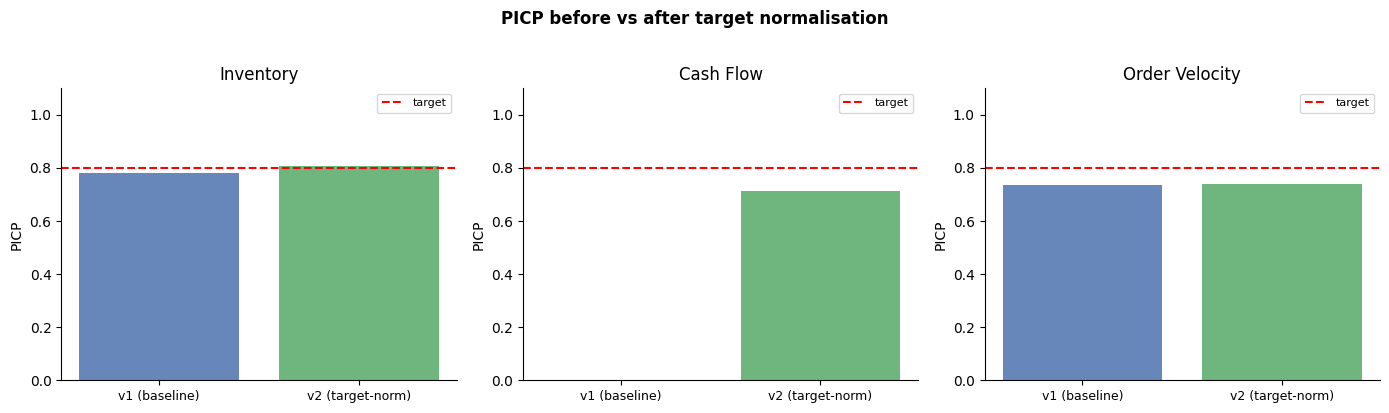

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = {'v1 (baseline)': v1, 'v2 (target-norm)': v2}
x = np.arange(len(models)); w = 0.35; colors = ['#4C72B0','#55A868']

for ax, target in zip(axes, TARGETS):
    picps = [r[target]['calibration'] for r in models.values()]
    ax.bar(x, picps, color=colors, alpha=0.85)
    ax.axhline(0.80, color='red', linestyle='--', lw=1.5, label='target')
    ax.set_xticks(x); ax.set_xticklabels(list(models.keys()), fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel('PICP'); ax.set_title(SHORT[target])
    ax.legend(fontsize=8)
plt.suptitle('PICP before vs after target normalisation', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


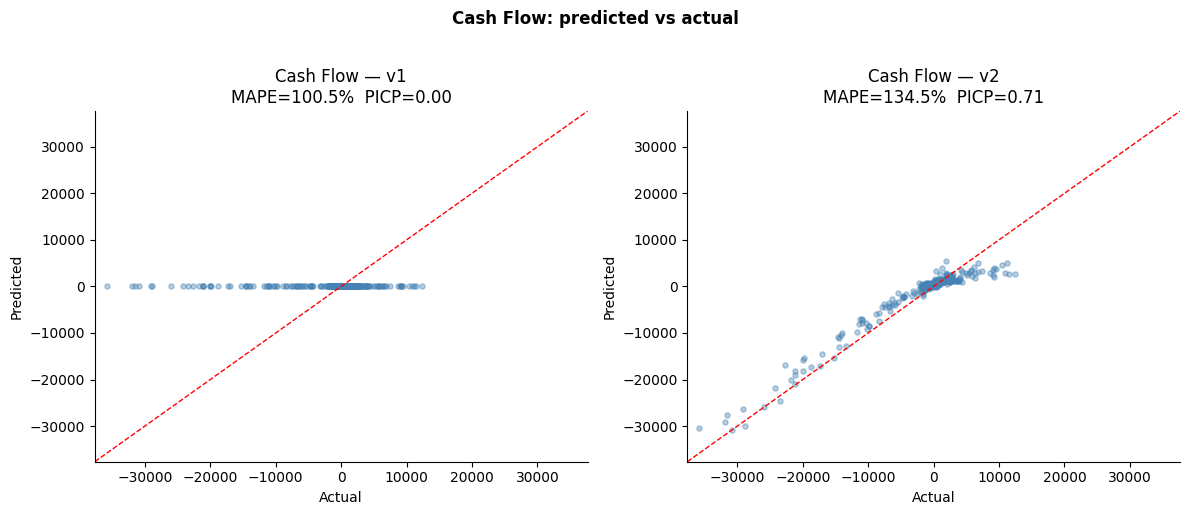

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, res) in zip(axes, {'v1': v1, 'v2': v2}.items()):
    r = res['label_cashflow_delta']
    ax.scatter(r['y_test'], r['y_pred'], alpha=0.4, s=14, color='steelblue')
    lim = max(np.abs(r['y_test']).max(), np.abs(r['y_pred']).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'Cash Flow — {name}\nMAPE={r["mape"]:.1f}%  PICP={r["calibration"]:.2f}')
plt.suptitle('Cash Flow: predicted vs actual', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Pass / Fail

In [6]:
print('PASS/FAIL — Transformer v2 cash flow PICP > 0.70 (up from 0.002)')
cf_picp = v2['label_cashflow_delta']['calibration']
status  = 'PASS ✓' if cf_picp > 0.70 else 'FAIL ✗'
print(f'  Cash Flow PICP: {cf_picp:.3f}  →  {status}')
print()
print('All targets:')
for t in TARGETS:
    v1m = v1[t]['mape']; v2m = v2[t]['mape']
    delta = v2m - v1m
    print(f'  {SHORT[t]:<18}  v1 MAPE={v1m:.1f}%  v2 MAPE={v2m:.1f}%  Δ={delta:+.1f}%')


PASS/FAIL — Transformer v2 cash flow PICP > 0.70 (up from 0.002)
  Cash Flow PICP: 0.712  →  PASS ✓

All targets:
  Inventory           v1 MAPE=43.2%  v2 MAPE=94.3%  Δ=+51.2%
  Cash Flow           v1 MAPE=100.5%  v2 MAPE=134.5%  Δ=+34.0%
  Order Velocity      v1 MAPE=64.3%  v2 MAPE=77.3%  Δ=+13.1%
